<a href="https://colab.research.google.com/github/anshubilawliya230456-web/ML-Lab/blob/main/Linear_Regression_stock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [26]:

file_path = "/content/drive/MyDrive/stock_data.csv"
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)

   Unnamed: 0     Stock_1     Stock_2    Stock_3     Stock_4     Stock_5
0  2020-01-01  101.764052  100.160928  99.494642   99.909756  101.761266
1  2020-01-02  102.171269   99.969968  98.682973  100.640755  102.528643
2  2020-01-03  103.171258   99.575237  98.182139  100.574847  101.887811
3  2020-01-04  105.483215   99.308641  97.149381  100.925017  101.490049
4  2020-01-05  107.453175   98.188428  99.575396  101.594411  101.604283
Index(['Unnamed: 0', 'Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5'], dtype='object')


In [27]:
X = np.arange(len(df)).astype(float)
y = df['Stock_1'].values.astype(float)

X = (X - X.mean()) / X.std()
y = (y - y.mean()) / y.std()

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/6, random_state=0
)

In [29]:
class MyLinearRegression:
    def __init__(self, weight=0, bias=0, learning_rate=0.001, iterations=1000):
        self.weight = weight
        self.bias = bias
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.cost_trend = []

    def predict(self, x):
        return [self.weight * xi + self.bias for xi in x]

    def cost_function(self, x, y):
        n = len(x)
        return sum((y[i] - (self.weight * x[i] + self.bias))**2 for i in range(n)) / (2*n)

    def train(self, x, y):
        n = len(x)

        for i in range(self.iterations):
            y_pred = self.predict(x)

            # gradients
            dw = sum((y_pred[j] - y[j]) * x[j] for j in range(n)) / n
            db = sum((y_pred[j] - y[j]) for j in range(n)) / n

            # update
            self.weight -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            cost = self.cost_function(x, y)
            self.cost_trend.append(cost)

            print(f"Iter {i} | W: {self.weight:.4f} | B: {self.bias:.4f} | Cost: {cost:.4f}")

In [30]:
model = MyLinearRegression(learning_rate=0.001, iterations=1000)
model.train(X_train, y_train)

print("\nFinal Weight:", model.weight)
print("Final Bias:", model.bias)

Iter 0 | W: -0.0004 | B: -0.0000 | Cost: 0.5256
Iter 1 | W: -0.0009 | B: -0.0000 | Cost: 0.5255
Iter 2 | W: -0.0013 | B: -0.0000 | Cost: 0.5253
Iter 3 | W: -0.0017 | B: -0.0000 | Cost: 0.5251
Iter 4 | W: -0.0021 | B: -0.0000 | Cost: 0.5249
Iter 5 | W: -0.0026 | B: -0.0001 | Cost: 0.5247
Iter 6 | W: -0.0030 | B: -0.0001 | Cost: 0.5246
Iter 7 | W: -0.0034 | B: -0.0001 | Cost: 0.5244
Iter 8 | W: -0.0038 | B: -0.0001 | Cost: 0.5242
Iter 9 | W: -0.0042 | B: -0.0001 | Cost: 0.5240
Iter 10 | W: -0.0047 | B: -0.0001 | Cost: 0.5238
Iter 11 | W: -0.0051 | B: -0.0001 | Cost: 0.5237
Iter 12 | W: -0.0055 | B: -0.0001 | Cost: 0.5235
Iter 13 | W: -0.0059 | B: -0.0001 | Cost: 0.5233
Iter 14 | W: -0.0064 | B: -0.0001 | Cost: 0.5231
Iter 15 | W: -0.0068 | B: -0.0002 | Cost: 0.5229
Iter 16 | W: -0.0072 | B: -0.0002 | Cost: 0.5228
Iter 17 | W: -0.0076 | B: -0.0002 | Cost: 0.5226
Iter 18 | W: -0.0080 | B: -0.0002 | Cost: 0.5224
Iter 19 | W: -0.0084 | B: -0.0002 | Cost: 0.5222
Iter 20 | W: -0.0089 | B: -0.0

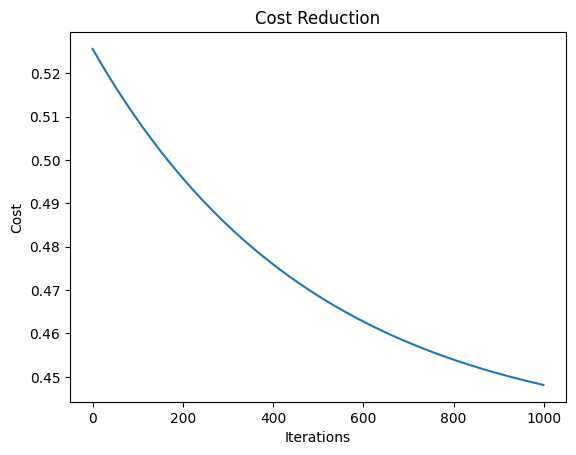

In [31]:
plt.plot(range(len(model.cost_trend)), model.cost_trend)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction")
plt.show()

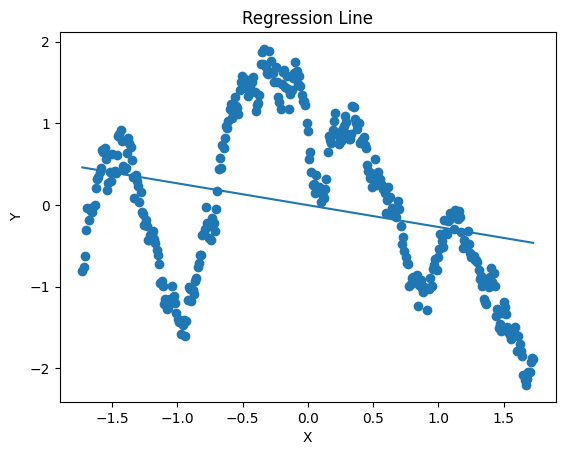

In [32]:
plt.scatter(X, y)

x_vals = np.array([min(X), max(X)])
y_vals = model.bias + model.weight * x_vals

plt.plot(x_vals, y_vals)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regression Line")
plt.show()

In [33]:
y_pred = model.predict(X_test)

print("Predicted vs Actual")
print("-"*40)

errors = []
for i in range(len(y_pred)):
    pred = float(y_pred[i])
    actual = float(y_test[i])
    diff = abs(pred - actual)
    errors.append(diff)
    print(f"Pred: {pred:.2f} | Actual: {actual:.2f} | Diff: {diff:.2f}")

print("-"*40)
print("Average Error:", sum(errors)/len(errors))

Predicted vs Actual
----------------------------------------
Pred: 0.19 | Actual: -0.22 | Diff: 0.41
Pred: -0.20 | Actual: -0.39 | Diff: 0.20
Pred: 0.35 | Actual: 0.23 | Diff: 0.12
Pred: 0.39 | Actual: 0.41 | Diff: 0.02
Pred: 0.26 | Actual: -1.44 | Diff: 1.70
Pred: -0.42 | Actual: -1.64 | Diff: 1.22
Pred: 0.23 | Actual: -1.09 | Diff: 1.32
Pred: -0.33 | Actual: -0.32 | Diff: 0.01
Pred: -0.15 | Actual: 0.41 | Diff: 0.56
Pred: 0.44 | Actual: -0.05 | Diff: 0.49
Pred: 0.16 | Actual: 1.24 | Diff: 1.08
Pred: 0.10 | Actual: 1.22 | Diff: 1.12
Pred: -0.21 | Actual: -0.72 | Diff: 0.52
Pred: -0.27 | Actual: -0.80 | Diff: 0.54
Pred: -0.30 | Actual: -0.11 | Diff: 0.19
Pred: -0.07 | Actual: 0.92 | Diff: 0.99
Pred: -0.29 | Actual: -0.36 | Diff: 0.07
Pred: 0.20 | Actual: -0.22 | Diff: 0.42
Pred: -0.10 | Actual: 1.00 | Diff: 1.10
Pred: 0.10 | Actual: 1.15 | Diff: 1.05
Pred: 0.10 | Actual: 1.25 | Diff: 1.15
Pred: -0.05 | Actual: 0.85 | Diff: 0.89
Pred: 0.31 | Actual: -0.46 | Diff: 0.77
Pred: -0.28 | Actu